# Installing and Using the bagelR Package

## Installing bagelR

The **bagelR** package can be installed via an interactive **R** session using the following code.

In [1]:
if(system.file(package = "bagelR") != "")
    {
      remove.packages("bagelR")
    }
library("remotes")
install_github("grosed/bagel/bagelR",force=TRUE)

Removing package from ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)




Running `R CMD build`...



* checking for file ‘/tmp/Rtmp6JuGYd/remotes3e606031e49652/grosed-bagel-77de8d1/bagelR/DESCRIPTION’ ... OK
* preparing ‘bagelR’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* installing the package to process help pages
* saving partial Rd database
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘bagelR_1.0.0.tar.gz’


Installing package into ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)



## Check package version

In [2]:
packageVersion("bagelR")

[1] ‘1.0.0’

## Using bagelR - 1 : Detecting Change in Mean with Known Variance

#### Load the bagel package

In [3]:
library(bagelR)


Attaching package: ‘bagelR’


The following object is masked from ‘package:stats’:

    time




### Example 1 - no change

#### Define the feature vector function 

These functions for the **feature vector** and the **prior** correspeond to example 1 in "**Bagel : A Fast Baysian Online Changepoint Detection Algorithm for Linear Models**" *Fearnhead et al.*

In [4]:
feature_vector <- function(t,tau)
{
  if(tau == 0)
  {
    M <- matrix(c(0),nc=1,nr=1)       
    M[1,1] <- 1
    return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=2)       
    M[1,1] <- 1
    if(t > tau)
    {
      M[2,1] <- 1
    }
    return(M)
  }
}

#### Define the prior function

In [5]:

prior <- function(t)
{
  mu1 <- 1;
  delta <- c(5,1)
  if(t == 1)
  {
    mu <- matrix(c(mu1),nc=1,nr=1)
    sigma <- delta[1]*diag(1)
    return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(mu1,0),nc=1,nr=2)
  sigma <- diag(delta)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Generate some data - no change

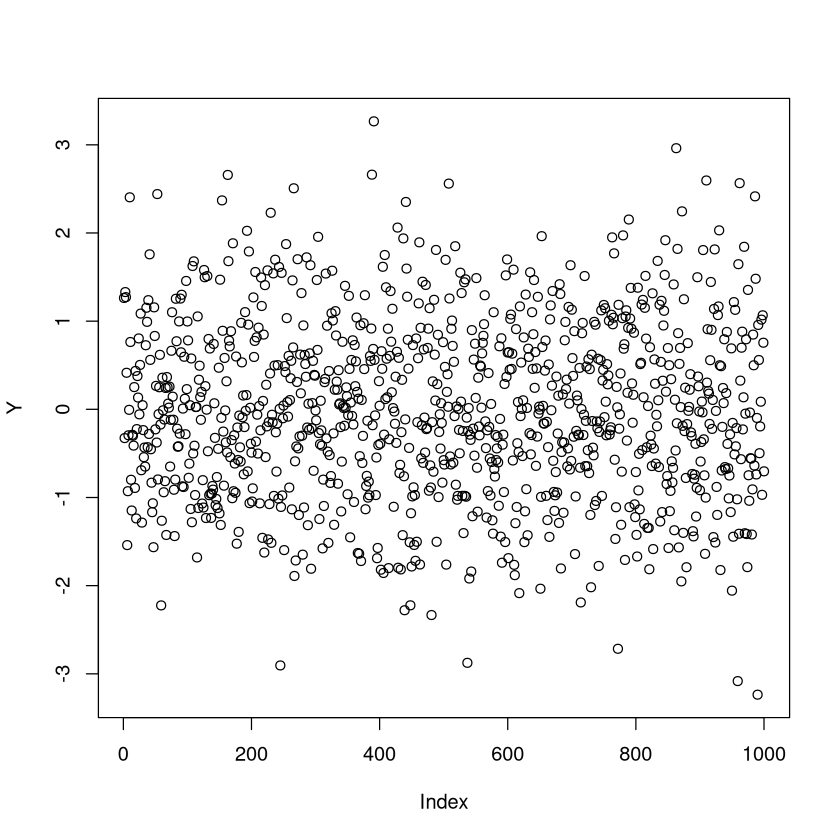

In [6]:
set.seed(0)
Y <- rnorm(1000,0,1)
plot(Y)

#### Set model parameters 

In [7]:
p <- 1.0;
p0 <- 0.9;
noise_sd <- 1.0;
max_particles <- 500
threshold <- 0.8

#### Offline analysis

In [8]:
results <- bagel_offline(feature_vector,prior,p0,p,noise_sd,max_particles,threshold,Y)

#### Visualise weight at tau = 0

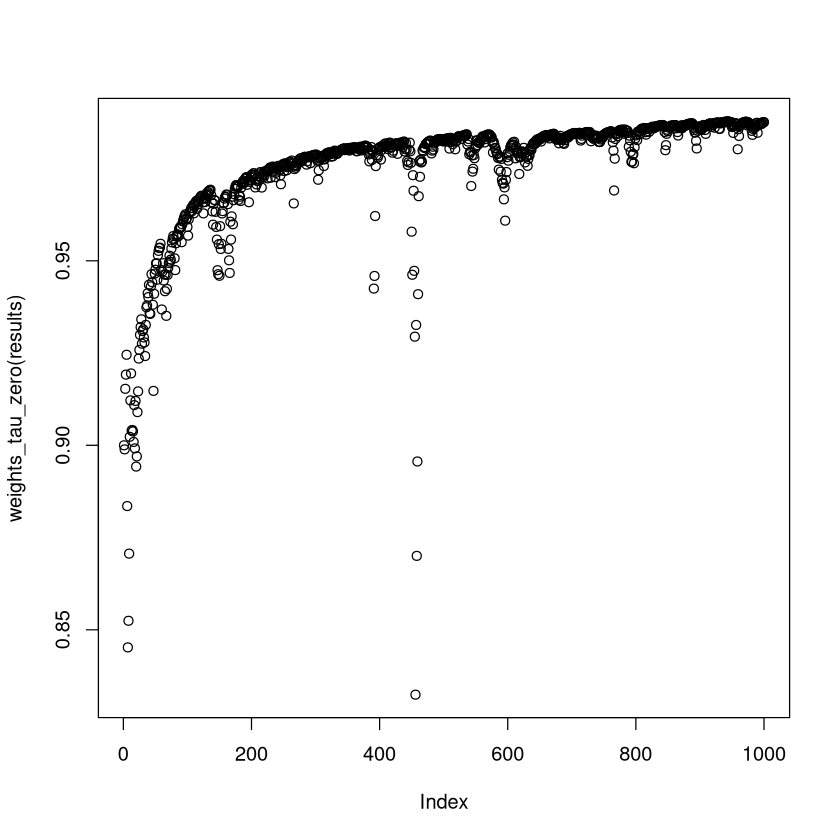

In [9]:
plot(weights_tau_zero(results))

#### Example 2 - single change in mean

#### Generate some data - change at t = 501 

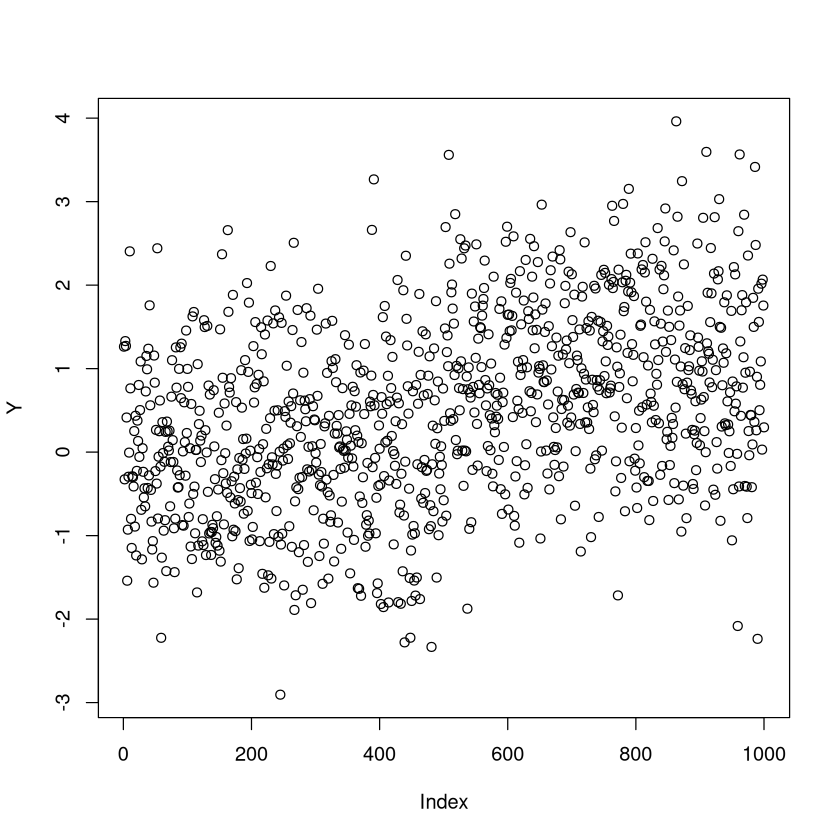

In [10]:
set.seed(0)
Y <- c(rnorm(500,0,1),rnorm(500,1,1))
plot(Y)

#### Offline analysis

In [11]:
results <- bagel_offline(feature_vector,prior,p0,p,noise_sd,max_particles,threshold,Y)

#### Visualise weight at tau = 0

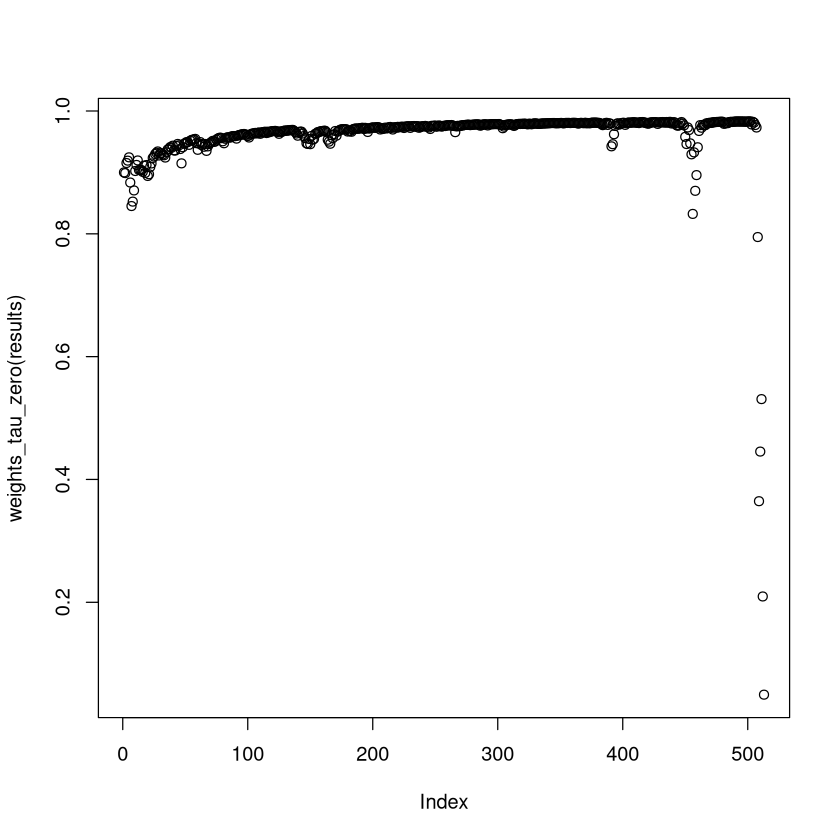

In [12]:
plot(weights_tau_zero(results))

#### Determine time at which change was detected

In [13]:
time(results)

[1] 513

#### Visulaise the weights after detection of change

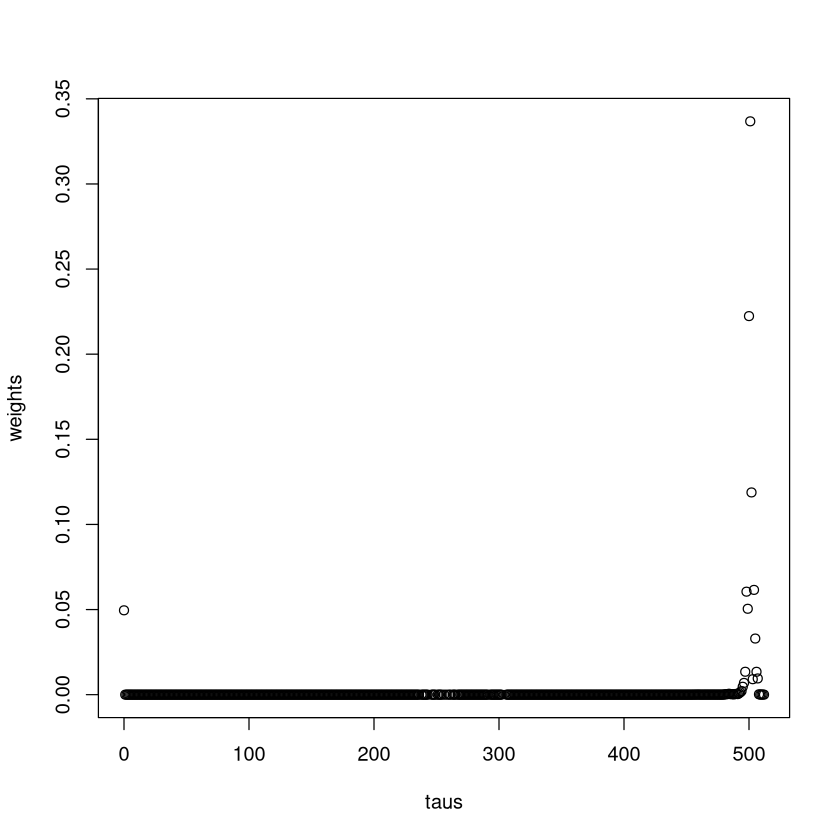

In [14]:
weights <- weights(results)
taus <- taus(results)
plot(taus,weights)

### Determine tau for maximum weight post change detection

In [15]:
taus[which.max(weights)]

[1] 501

#### Example 2 - single change in mean different prior

#### Define new prior

In [16]:
prior <- function(t)
{
  mu1<-1;
  delta1<-1
  if(t == 1)
  {
    mu <- matrix(c(mu1),nc=1,nr=1)
    sigma <- delta1*diag(1)
    return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(mu1,0),nc=1,nr=2)
  sigma <- delta1*matrix(c(1,-1,-1,2),nr=2,nc=2)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Offline analysis

In [17]:
results <- bagel_offline(feature_vector,prior,p0,p,noise_sd,max_particles,threshold,Y)

#### Visualise weight at tau = 0

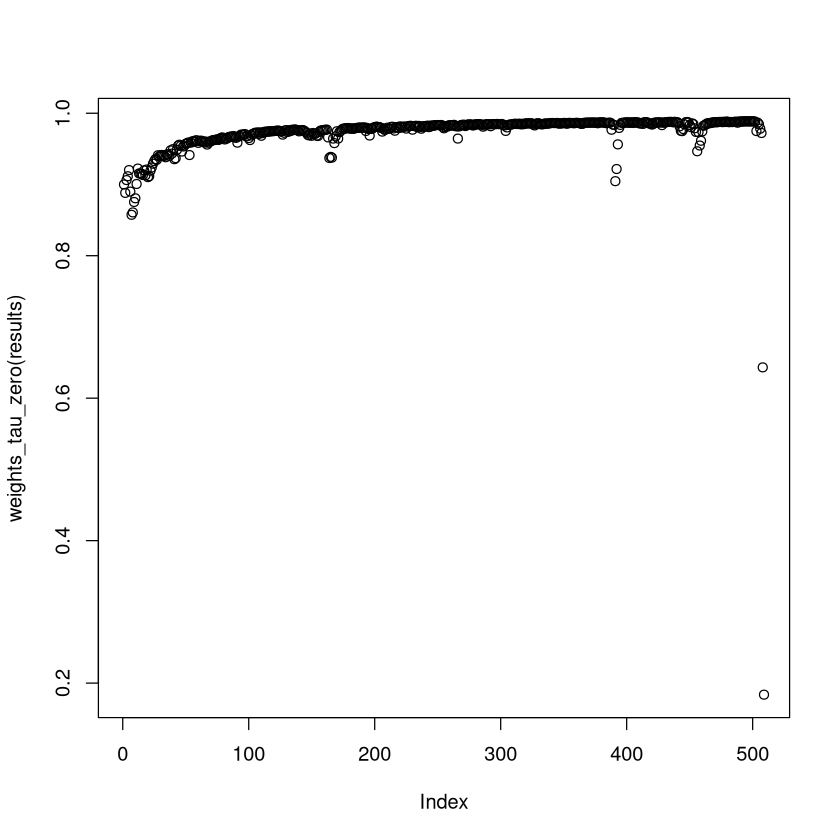

In [18]:
plot(weights_tau_zero(results))

#### Determine time at which change was detected

In [19]:
time(results)

[1] 509

#### Visulaise the weights after detection of change

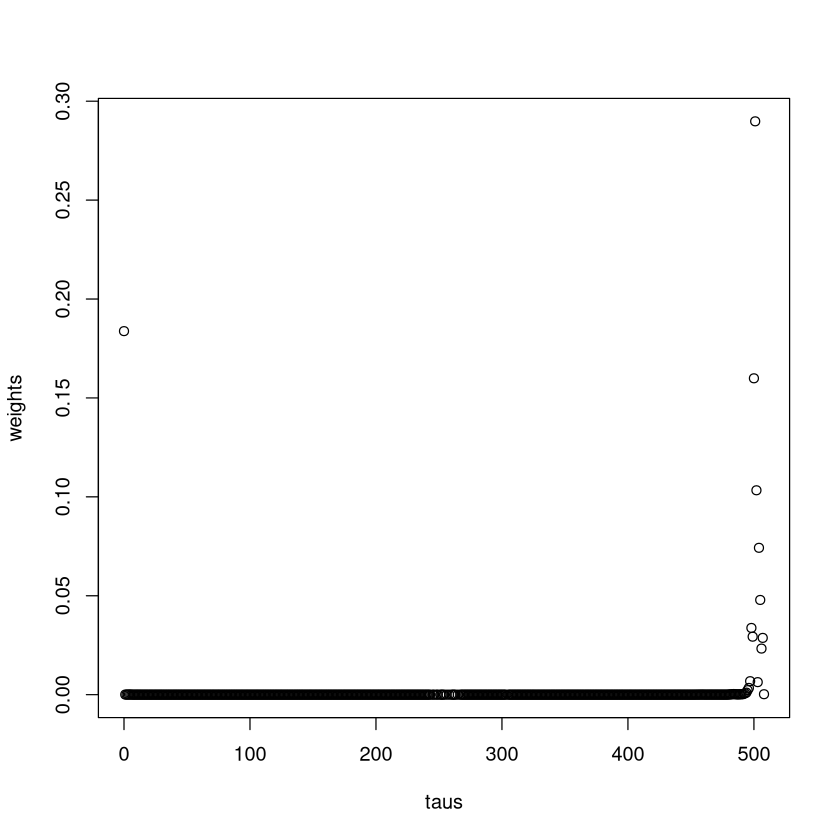

In [20]:
weights <- weights(results)
taus <- taus(results)
plot(taus,weights)

### Determine tau for maximum weight post change detection 

In [21]:
taus[which.max(weights)]

[1] 501

## Using bagelR - 2 : Detecting Change in Slope with Known Variance

### Example 1 - no change

#### Generate some data - no change

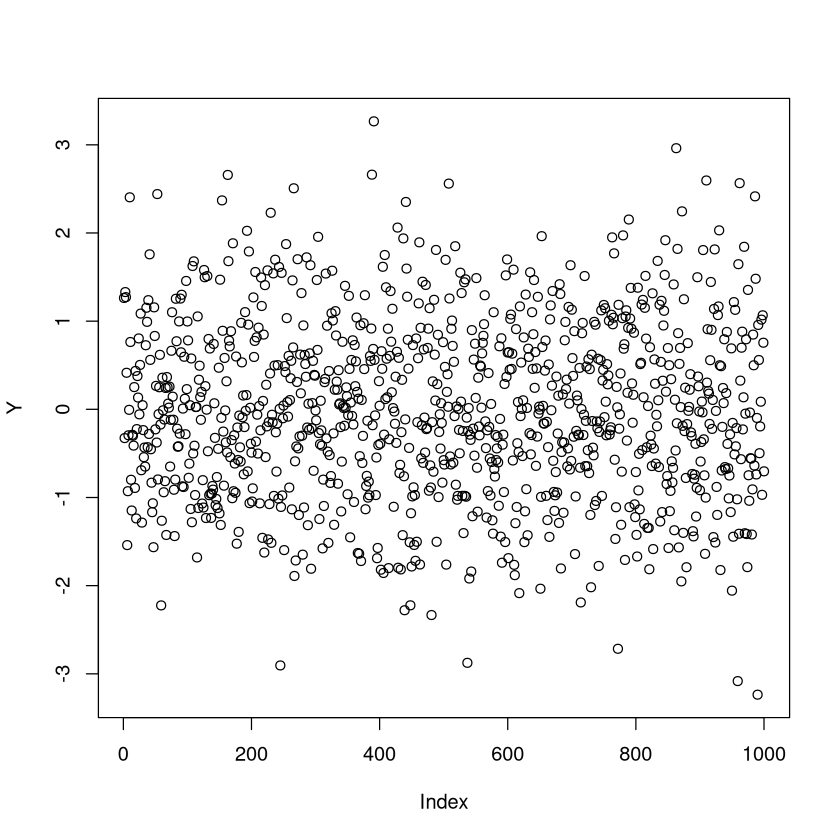

In [22]:
set.seed(0)
Y <- rnorm(1000,0,1)
plot(Y)

#### Define the feature vector function 

These functions for the **feature vector** and the **prior** correspeond to example 2 in "**Bagel : A Fast Baysian Online Changepoint Detection Algorithm for Linear Models**" *Fearnhead et al.*

In [23]:
feature_vector <- function(t,tau)
{
  if(tau == 0)
  {
     M <- matrix(c(0),nc=1,nr=2)	  
     M[1,1] <- 1
     M[2,1] <- t
     return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=4)	  
    M[1,1] <- 1
    M[2,1] <- t
    if(t > tau)
    {
      M[3,1] <- 1
      M[4,1] <- t
    }
  return(M)
  }
}

#### Define the prior function

In [24]:
prior <- function(t)
{
  if(t == 1)
  {
     mu <- matrix(c(0),nc=1,nr=2)
     sigma <- diag(2)
     return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(0),nc=1,nr=4)
  sigma <- diag(4)
  sigma[3,3] <- (t-1)*(t-1)
  sigma[4,3] <- sigma[3,4] <- -(t-1)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Set model parameters 

In [25]:
p <- 1.0;
p0 <- 0.9;
noise_sd <- 1.0;
max_particles <- 500
threshold <- 0.8

#### Offline analysis

In [26]:
results <- bagel_offline(feature_vector,prior,p0,p,noise_sd,max_particles,threshold,Y)

#### Visualise weight at tau = 0

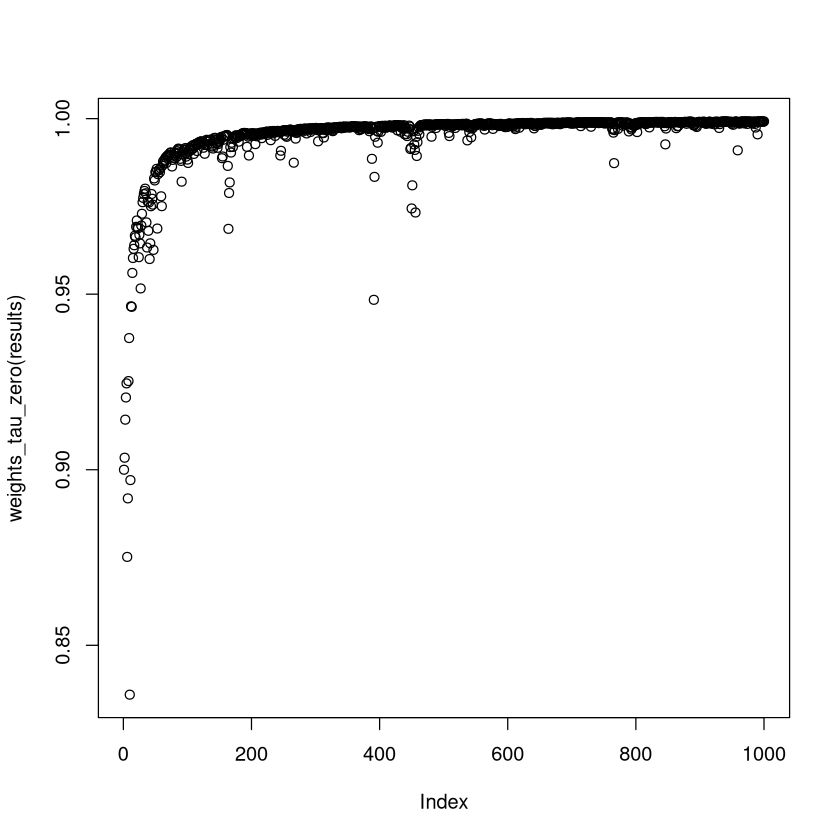

In [27]:
plot(weights_tau_zero(results))

### Example 2 - single change in slope

#### Generate data with change in slope at t = 1000

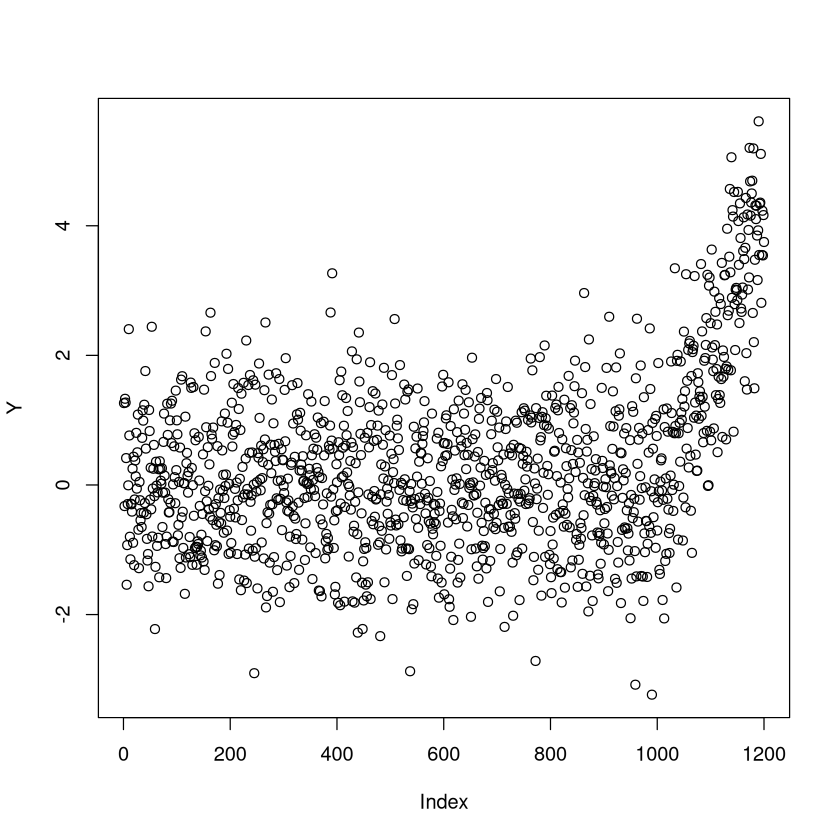

In [28]:
set.seed(0)
Y <- c(rnorm(1000,0,1),seq(1,200,1)/50 + rnorm(200,0,1))
plot(Y)

#### Offline analysis

In [29]:
results <- bagel_offline(feature_vector,prior,p0,p,noise_sd,max_particles,threshold,Y)

#### Visualise weight at tau = 0

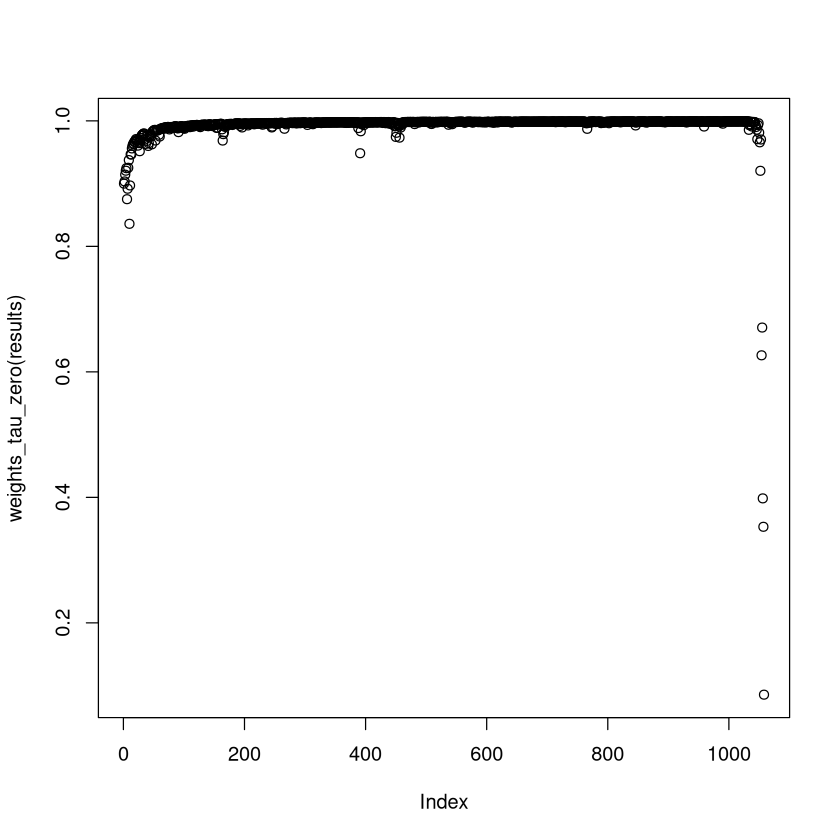

In [30]:
plot(weights_tau_zero(results))

#### Determine time at which change was detected

In [31]:
time(results)

[1] 1058

#### Visulaise the weights after detection of change

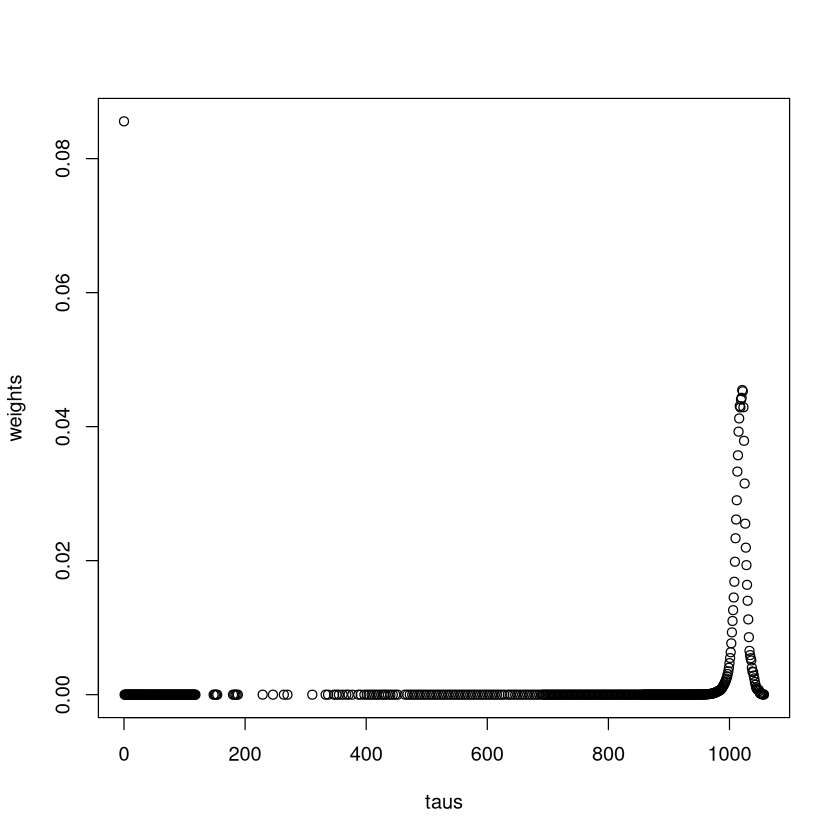

In [32]:
weights <- weights(results)
taus <- taus(results)
plot(taus,weights)

#### Locate the maximum weight for tau > 0

In [33]:
taus[which.max(weights[-1])]

[1] 1020

In [34]:
#### Generate some data - change at t = 501 

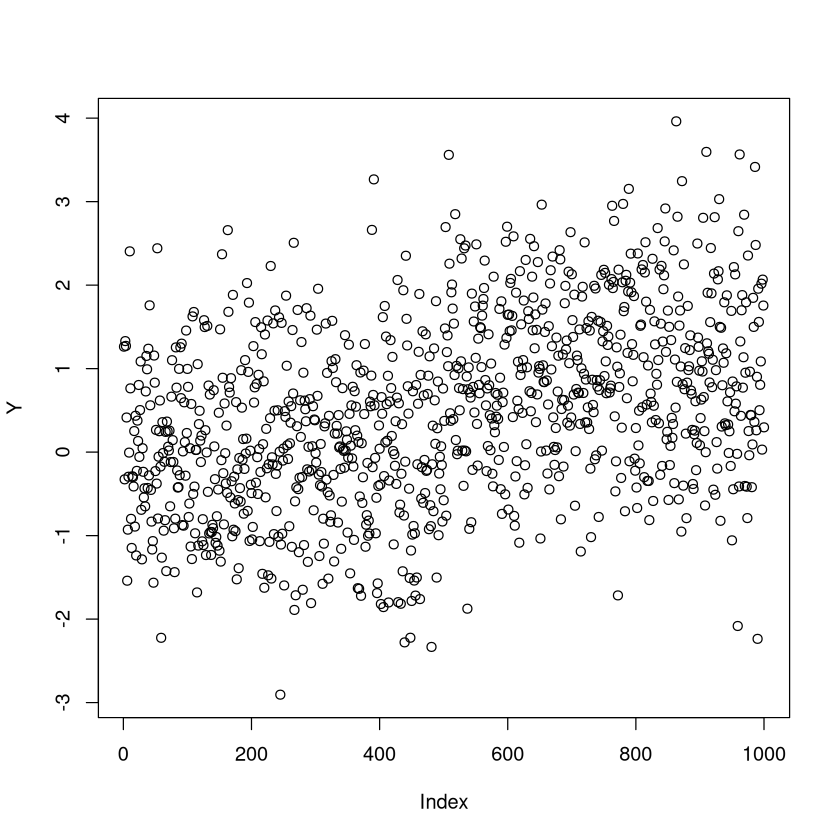

In [35]:
set.seed(0)
Y <- c(rnorm(500,0,1),rnorm(500,1,1))
plot(Y)

In [36]:
model <- bagel(feature_vector_ex1,prior.ex1.1,p0,p,s,n)

ERROR: Error in bagel(feature_vector_ex1, prior.ex1.1, p0, p, s, n): could not find function "bagel"


In [ ]:
w0s <- c()

In [ ]:
for(y in Y)
{
  # update the model with the most recent data and store the weight at tau = 0  
  w0 <- update(model,y)
  w0s <- c(w0s,w0) # log the result 
  if(1.0 - w0 > threshold)
      {
          break
      }
}

In [ ]:
plot(w0s)